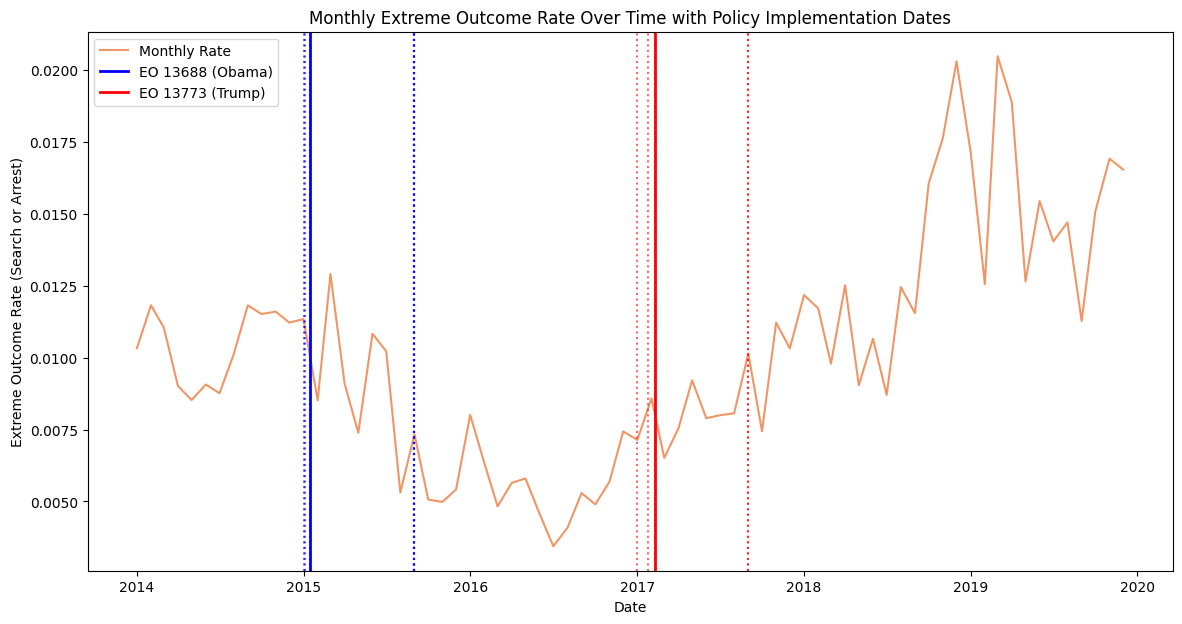

In [1]:
# updating Kaia's plot 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load data
final = pd.read_csv('teamb_final_data.csv')
policy_data = pd.read_csv('policy_data.csv')
policy_data = policy_data.iloc[:, :6]

# ensure datetime columns are proper datetime
final['datetime'] = pd.to_datetime(final['datetime'])
policy_data['effective_date'] = pd.to_datetime(policy_data['effective_date'])

# keep only policies implemented in or after 2014
policy_subset = policy_data[policy_data['effective_date'] >= '2014-01-01']

# create month variable
final['month'] = final['datetime'].dt.to_period('M')

# calculate monthly extreme outcome rate
monthly_outcome = final.groupby('month')['extreme_cases'].mean().reset_index()

# convert period to timestamp
monthly_outcome['month'] = monthly_outcome['month'].dt.to_timestamp()

# create rolling average (6-month smoothing)
monthly_outcome['rolling_trend'] = monthly_outcome['extreme_cases'].rolling(window=6).mean()

plt.figure(figsize=(14,7))

# main line (orange)
plt.plot(monthly_outcome['month'], monthly_outcome['extreme_cases'],
         color='#E65100', alpha=0.6, label='Monthly Rate')

# policy lines with color split
for idx, row in policy_subset.iterrows():
    if row['effective_date'] < pd.Timestamp('2017-01-01'):
        plt.axvline(row['effective_date'], linestyle=':', color='blue', alpha=0.6)
    else:
        plt.axvline(row['effective_date'], linestyle=':', color='red', alpha=0.6)

# adding solid lines to the exec orders we wanna highlight
# Obama Executive Order 13688 (Jan 16, 2015)
plt.axvline(pd.Timestamp('2015-01-16'),
            color='blue', linewidth=2,
            label='EO 13688 (Obama)')

# Trump Executive Order 13773 (Feb 9, 2017)
plt.axvline(pd.Timestamp('2017-02-09'),
            color='red', linewidth=2,
            label='EO 13773 (Trump)')

plt.title('Monthly Extreme Outcome Rate Over Time with Policy Implementation Dates')
plt.xlabel('Date')
plt.ylabel('Extreme Outcome Rate (Search or Arrest)')

plt.legend()
plt.savefig('/Users/sarahmoffitt/Downloads/policy.png',
            dpi=300,
            bbox_inches='tight')
plt.show()

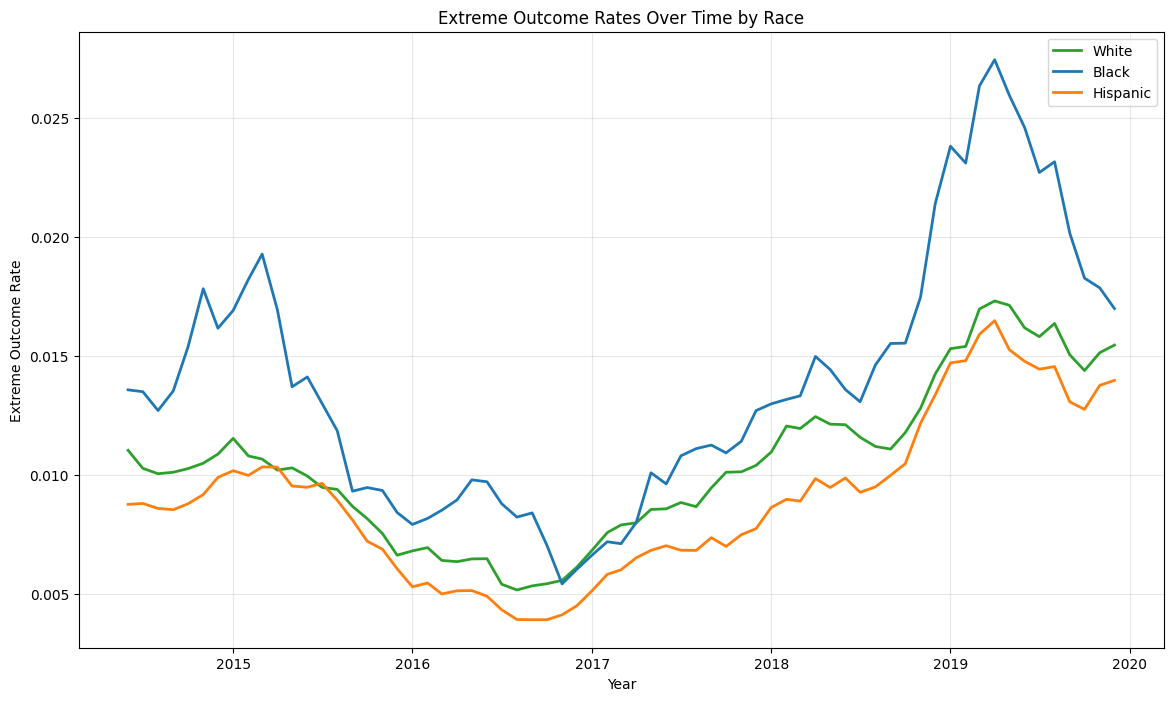

In [2]:
#making this demographics plot easier to read

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('teamb_final_data.csv')

# Ensure datetime is correct
df['datetime'] = pd.to_datetime(df['datetime'])

# Create a single race column from one hot encoded variables
df['race'] = 'Other'
df.loc[df['subject_race_white'] == 1, 'race'] = 'White'
df.loc[df['subject_race_black'] == 1, 'race'] = 'Black'
df.loc[df['subject_race_hispanic'] == 1, 'race'] = 'Hispanic'

# Create monthly time variable 
df['month'] = df['datetime'].dt.to_period('M')

# Calculate extreme outcome rates by race and month
outcome_time = df.groupby(['month', 'race'])['extreme_cases'].mean().unstack()

# Convert month index to timestamp
outcome_time.index = outcome_time.index.to_timestamp()

# Create 6 month rolling average
outcome_smooth = outcome_time[['White', 'Black', 'Hispanic']].rolling(window=6).mean()

# Plot manually to control colors
plt.figure(figsize=(14,8))

plt.plot(outcome_smooth.index, outcome_smooth['White'],
         color='#2ca02c', linewidth=2, label='White')

plt.plot(outcome_smooth.index, outcome_smooth['Black'],
         color='#1f77b4', linewidth=2, label='Black')

plt.plot(outcome_smooth.index, outcome_smooth['Hispanic'],
         color='#ff7f0e', linewidth=2, label='Hispanic')

plt.title("Extreme Outcome Rates Over Time by Race")
plt.xlabel("Year")
plt.ylabel("Extreme Outcome Rate")
plt.grid(True, alpha=0.3)
plt.legend()
#saving it to my comp
plt.savefig('/Users/sarahmoffitt/Downloads/demo.png',
            dpi=300,
            bbox_inches='tight')
plt.show()
